In [98]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist

In [99]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)

print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


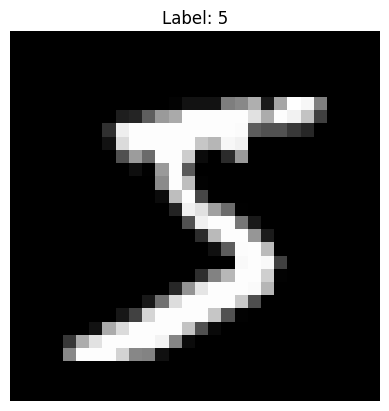

In [100]:
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

In [101]:
# Check the shape of one image
print("Original shape:", X_train[0].shape)

# Flatten the image
image_flattened = X_train[0].flatten()

print("Flattened shape:", image_flattened.shape)
print("Number of pixels:", len(image_flattened))

Original shape: (28, 28)
Flattened shape: (784,)
Number of pixels: 784


In [102]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [103]:
# Reload the original MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize pixel values only once
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Check the values
print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [104]:
# Flatten the images

X_train_flat = X_train.reshape(X_train.shape[0], 784)
X_test_flat = X_test.reshape(X_test.shape[0], 784)

print("Training data shape:", X_train_flat.shape)
print("Testing data shape:", X_test_flat.shape)

Training data shape: (60000, 784)
Testing data shape: (10000, 784)


In [105]:
print("Original image shape:", X_train[0].shape)
print("Flattened image shape:", X_train_flat[0].shape)
print("Actual label:", y_train[0])

Original image shape: (28, 28)
Flattened image shape: (784,)
Actual label: 5


In [106]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [107]:
ann_model = Sequential([
    Dense(128, activation="relu", input_shape=(784,)),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

ann_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [108]:
ann_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [109]:
history_ann = ann_model.fit(
    X_train_flat,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8989 - loss: 0.3603 - val_accuracy: 0.9577 - val_loss: 0.1445
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9585 - loss: 0.1459 - val_accuracy: 0.9693 - val_loss: 0.1076
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9697 - loss: 0.1013 - val_accuracy: 0.9658 - val_loss: 0.1121
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9775 - loss: 0.0777 - val_accuracy: 0.9747 - val_loss: 0.0874
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9811 - loss: 0.0610 - val_accuracy: 0.9755 - val_loss: 0.0843
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9852 - loss: 0.0490 - val_accuracy: 0.9797 - val_loss: 0.0747
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9879 - loss: 0.0390 - val_accuracy: 0.9797 - val_loss: 0.0744
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9897 - loss: 0.0326 - val_accuracy: 0.

In [110]:
test_loss, test_accuracy = ann_model.evaluate(
    X_test_flat,
    y_test,
    verbose=0
)

print("Baseline ANN Test Accuracy:", test_accuracy)

Baseline ANN Test Accuracy: 0.9779999852180481


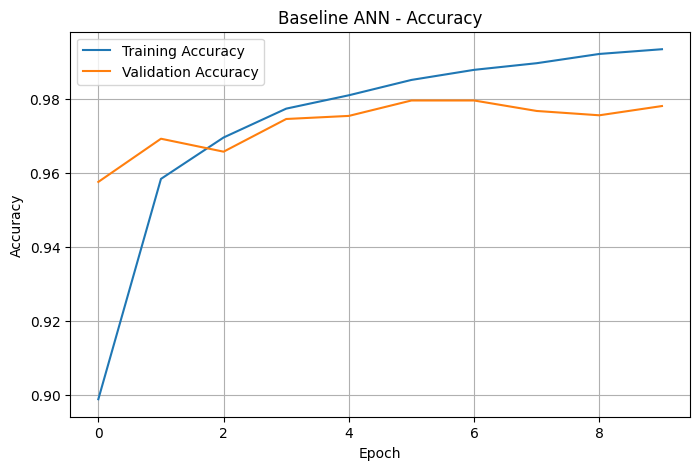

In [111]:
plt.figure(figsize=(8, 5))

plt.plot(history_ann.history["accuracy"], label="Training Accuracy")
plt.plot(history_ann.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline ANN - Accuracy")
plt.legend()
plt.grid()
plt.show()

In [112]:
predictions = ann_model.predict(X_test_flat[:10])

predicted_labels = np.argmax(predictions, axis=1)

print("Actual labels:   ", y_test[:10])
print("Predicted labels:", predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Actual labels:    [7 2 1 0 4 1 4 9 5 9]
Predicted labels: [7 2 1 0 4 1 4 9 6 9]


In [113]:
from sklearn.neural_network import BernoulliRBM

In [114]:
rbm = BernoulliRBM(
    n_components=128,
    learning_rate=0.01,
    batch_size=128,
    n_iter=10,
    random_state=42,
    verbose=True
)

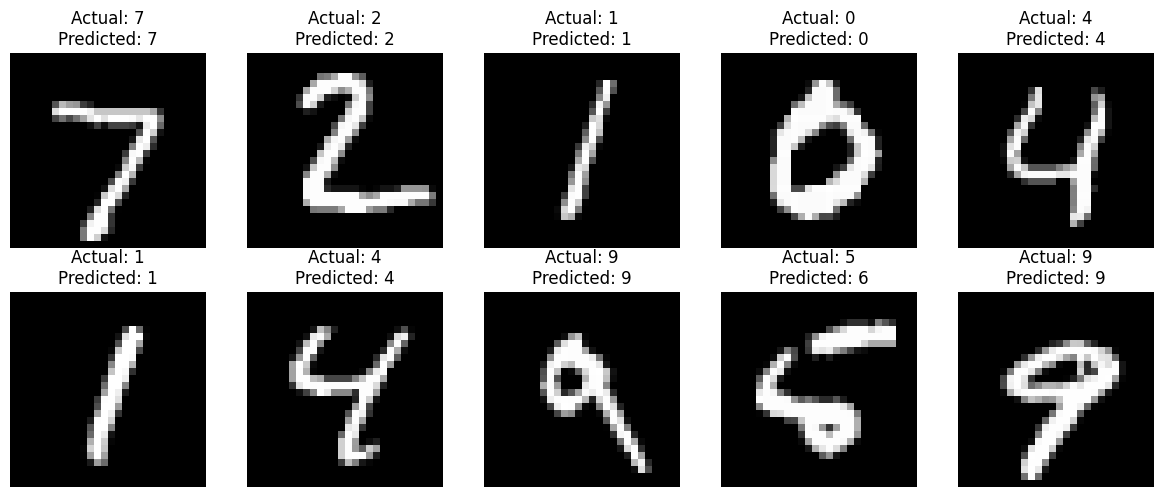

In [115]:
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i], cmap="gray")
    plt.title(f"Actual: {y_test[i]}\nPredicted: {predicted_labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [116]:
rbm.fit(X_train_flat)

[BernoulliRBM] Iteration 1, pseudo-likelihood = -192.77, time = 3.88s
[BernoulliRBM] Iteration 2, pseudo-likelihood = -160.99, time = 7.33s
[BernoulliRBM] Iteration 3, pseudo-likelihood = -147.07, time = 4.98s
[BernoulliRBM] Iteration 4, pseudo-likelihood = -138.93, time = 5.64s
[BernoulliRBM] Iteration 5, pseudo-likelihood = -132.16, time = 6.00s
[BernoulliRBM] Iteration 6, pseudo-likelihood = -127.25, time = 4.96s
[BernoulliRBM] Iteration 7, pseudo-likelihood = -123.17, time = 7.41s
[BernoulliRBM] Iteration 8, pseudo-likelihood = -119.57, time = 4.94s
[BernoulliRBM] Iteration 9, pseudo-likelihood = -116.41, time = 7.41s
[BernoulliRBM] Iteration 10, pseudo-likelihood = -113.95, time = 4.96s


BernoulliRBM(batch_size=128, learning_rate=0.01, n_components=128,
             random_state=42, verbose=True)

In [117]:
verbose=True

In [118]:
X_train_rbm = rbm.transform(X_train_flat)
X_test_rbm = rbm.transform(X_test_flat)

print("Original training shape:", X_train_flat.shape)
print("RBM training shape:", X_train_rbm.shape)

print("Original testing shape:", X_test_flat.shape)
print("RBM testing shape:", X_test_rbm.shape)

Original training shape: (60000, 784)
RBM training shape: (60000, 128)
Original testing shape: (10000, 784)
RBM testing shape: (10000, 128)


In [119]:
rbm_ann_model = Sequential([
    Dense(64, activation="relu", input_shape=(128,)),
    Dense(32, activation="relu"),
    Dense(10, activation="softmax")
])

rbm_ann_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,666 (41.66 KB)

 Trainable params: 10,666 (41.66 KB)

 Non-trainable params: 0 (0.00 B)

In [120]:
rbm_ann_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [121]:
history_rbm_ann = rbm_ann_model.fit(
    X_train_rbm,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8370 - loss: 0.5663 - val_accuracy: 0.9227 - val_loss: 0.2639
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9135 - loss: 0.2854 - val_accuracy: 0.9378 - val_loss: 0.2104
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9282 - loss: 0.2367 - val_accuracy: 0.9510 - val_loss: 0.1731
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9367 - loss: 0.2090 - val_accuracy: 0.9532 - val_loss: 0.1591
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9409 - loss: 0.1886 - val_accuracy: 0.9527 - val_loss: 0.1568
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9452 - loss: 0.1747 - val_accuracy: 0.9605 - val_loss: 0.1428
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9499 - loss: 0.1625 - val_accuracy: 0.9627 - val_loss: 0.1343
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9518 - loss: 0.1562 - val_accuracy: 0.

In [122]:
X_train_rbm

array([[9.9813122e-01, 5.5127990e-01, 8.1318337e-01, ..., 8.6769992e-01,
        5.3394848e-01, 3.1330112e-01],
       [9.7688735e-06, 7.7048391e-01, 7.5562291e-02, ..., 1.9620355e-05,
        5.0416696e-01, 9.9798238e-01],
       [1.8938469e-04, 6.5476769e-01, 9.9832422e-01, ..., 2.3359647e-03,
        8.7709153e-01, 4.7753947e-03],
       ...,
       [9.9646360e-01, 1.9957861e-02, 9.8484045e-01, ..., 9.2049962e-01,
        1.5698565e-02, 5.0267801e-03],
       [1.5712778e-04, 3.9061931e-01, 1.5393140e-02, ..., 3.8303627e-04,
        7.0085162e-01, 9.9766123e-01],
       [1.0861414e-03, 7.0101358e-03, 6.8610124e-03, ..., 6.0764670e-01,
        3.2484420e-03, 5.2454635e-03]], dtype=float32)

In [123]:
X_train_flat

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [124]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [125]:
rbm_ann_loss, rbm_ann_accuracy = rbm_ann_model.evaluate(
    X_test_rbm,
    y_test,
    verbose=0
)

print("RBM + ANN Test Accuracy:", rbm_ann_accuracy)

RBM + ANN Test Accuracy: 0.9559999704360962


IMPROVED V2

In [126]:
rbm_256 = BernoulliRBM(
    n_components=256,
    learning_rate=0.01,
    batch_size=128,
    n_iter=20,
    random_state=42,
    verbose=True
)

In [127]:
rbm_256.fit(X_train_flat)

[BernoulliRBM] Iteration 1, pseudo-likelihood = -170.93, time = 8.17s
[BernoulliRBM] Iteration 2, pseudo-likelihood = -144.38, time = 9.75s
[BernoulliRBM] Iteration 3, pseudo-likelihood = -132.79, time = 8.18s
[BernoulliRBM] Iteration 4, pseudo-likelihood = -124.53, time = 10.18s
[BernoulliRBM] Iteration 5, pseudo-likelihood = -117.96, time = 10.21s
[BernoulliRBM] Iteration 6, pseudo-likelihood = -113.17, time = 7.76s
[BernoulliRBM] Iteration 7, pseudo-likelihood = -109.33, time = 10.10s
[BernoulliRBM] Iteration 8, pseudo-likelihood = -106.19, time = 10.16s
[BernoulliRBM] Iteration 9, pseudo-likelihood = -103.37, time = 7.84s
[BernoulliRBM] Iteration 10, pseudo-likelihood = -100.94, time = 9.78s
[BernoulliRBM] Iteration 11, pseudo-likelihood = -98.90, time = 10.11s
[BernoulliRBM] Iteration 12, pseudo-likelihood = -96.89, time = 7.75s
[BernoulliRBM] Iteration 13, pseudo-likelihood = -95.11, time = 9.50s
[BernoulliRBM] Iteration 14, pseudo-likelihood = -93.73, time = 10.07s
[BernoulliRBM

BernoulliRBM(batch_size=128, learning_rate=0.01, n_iter=20, random_state=42,
             verbose=True)

In [128]:
X_train_rbm256 = rbm_256.transform(X_train_flat)
X_test_rbm256 = rbm_256.transform(X_test_flat)

print("RBM-256 training shape:", X_train_rbm256.shape)
print("RBM-256 testing shape:", X_test_rbm256.shape)

RBM-256 training shape: (60000, 256)
RBM-256 testing shape: (10000, 256)


In [129]:
rbm256_ann = Sequential([
    Dense(128, activation="relu", input_shape=(256,)),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

rbm256_ann.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,802 (163.29 KB)

 Trainable params: 41,802 (163.29 KB)

 Non-trainable params: 0 (0.00 B)

In [130]:
rbm256_ann.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [131]:
history_rbm256 = rbm256_ann.fit(
    X_train_rbm256,
    y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8946 - loss: 0.3695 - val_accuracy: 0.9578 - val_loss: 0.1463
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9486 - loss: 0.1691 - val_accuracy: 0.9693 - val_loss: 0.1108
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9597 - loss: 0.1308 - val_accuracy: 0.9713 - val_loss: 0.0934
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9655 - loss: 0.1115 - val_accuracy: 0.9688 - val_loss: 0.0973
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9703 - loss: 0.0946 - val_accuracy: 0.9730 - val_loss: 0.0877
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9728 - loss: 0.0847 - val_accuracy: 0.9787 - val_loss: 0.0742
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9764 - loss: 0.0753 - val_accuracy: 0.9755 - val_loss: 0.0846
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9768 - loss: 0.0718 - val_accuracy: 0.

In [132]:
rbm256_loss, rbm256_accuracy = rbm256_ann.evaluate(
    X_test_rbm256,
    y_test,
    verbose=0
)

print("Improved RBM + ANN Test Accuracy:", rbm256_accuracy)

Improved RBM + ANN Test Accuracy: 0.9761000275611877


In [133]:
baseline_accuracy = test_accuracy
rbm_accuracy = rbm256_accuracy

difference = (rbm_accuracy - baseline_accuracy) * 100

print(f"Baseline ANN Accuracy: {baseline_accuracy * 100:.2f}%")
print(f"RBM + ANN Accuracy: {rbm_accuracy * 100:.2f}%")
print(f"Accuracy Difference: {difference:.2f}%")

Baseline ANN Accuracy: 97.80%
RBM + ANN Accuracy: 97.61%
Accuracy Difference: -0.19%


In [134]:
results = {
    "Baseline ANN": baseline_accuracy,
    "RBM + ANN (128 features)": rbm_ann_accuracy,
    "RBM + ANN (256 features)": rbm256_accuracy
}

for model, accuracy in results.items():
    print(f"{model}: {accuracy * 100:.2f}%")

Baseline ANN: 97.80%
RBM + ANN (128 features): 95.60%
RBM + ANN (256 features): 97.61%


In [135]:
from sklearn.metrics import classification_report, confusion_matrix

In [136]:
baseline_predictions = ann_model.predict(X_test_flat)

baseline_predicted_labels = np.argmax(
    baseline_predictions,
    axis=1
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [137]:
print("Baseline ANN Classification Report")
print(
    classification_report(
        y_test,
        baseline_predicted_labels
    )
)

Baseline ANN Classification Report
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.98      0.99      1135
           2       0.96      0.98      0.97      1032
           3       0.99      0.96      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.97      0.97       892
           6       0.98      0.98      0.98       958
           7       0.96      0.99      0.97      1028
           8       0.96      0.98      0.97       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [138]:
rbm_predictions = rbm256_ann.predict(X_test_rbm256)

rbm_predicted_labels = np.argmax(
    rbm_predictions,
    axis=1
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [139]:
print("RBM + ANN Classification Report")
print(
    classification_report(
        y_test,
        rbm_predicted_labels
    )
)

RBM + ANN Classification Report
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.98      0.96      0.97      1032
           3       0.95      0.98      0.97      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.97      0.98       892
           6       0.99      0.98      0.98       958
           7       0.98      0.96      0.97      1028
           8       0.96      0.98      0.97       974
           9       0.97      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



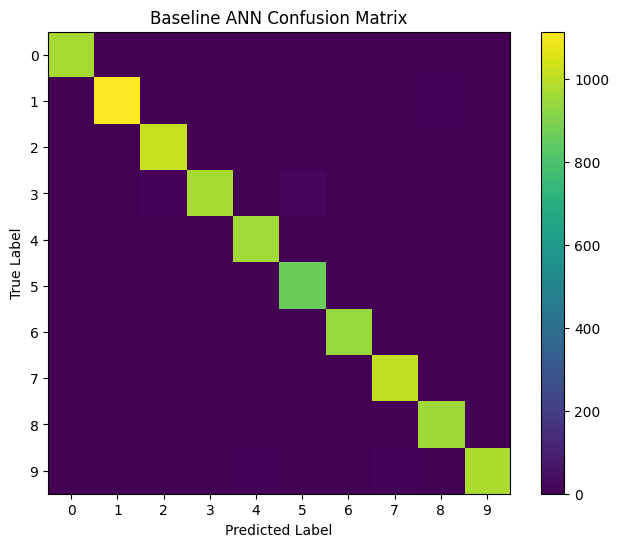

In [140]:
cm_baseline = confusion_matrix(
    y_test,
    baseline_predicted_labels
)

plt.figure(figsize=(8, 6))

plt.imshow(cm_baseline)

plt.title("Baseline ANN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

plt.xticks(range(10))
plt.yticks(range(10))

plt.show()

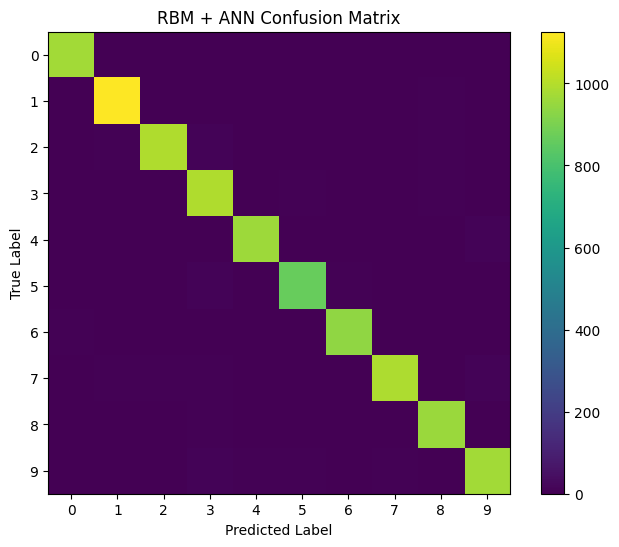

In [141]:
cm_rbm = confusion_matrix(
    y_test,
    rbm_predicted_labels
)

plt.figure(figsize=(8, 6))

plt.imshow(cm_rbm)

plt.title("RBM + ANN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

plt.xticks(range(10))
plt.yticks(range(10))

plt.show()

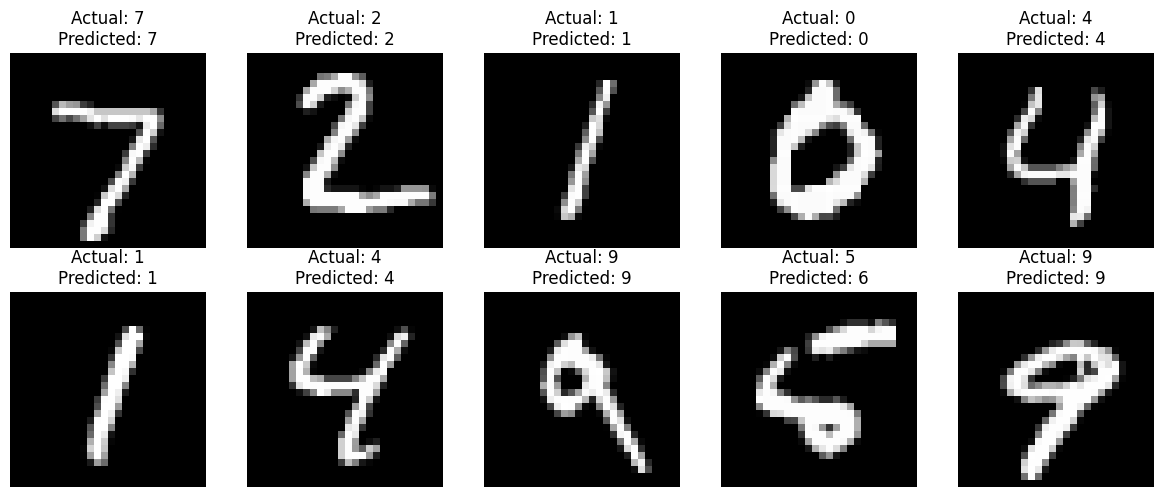

In [142]:
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(X_test[i], cmap="gray")

    plt.title(
        f"Actual: {y_test[i]}\nPredicted: {rbm_predicted_labels[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [143]:
incorrect_indices = np.where(
    rbm_predicted_labels != y_test
)[0]

print("Number of incorrect predictions:", len(incorrect_indices))

Number of incorrect predictions: 239


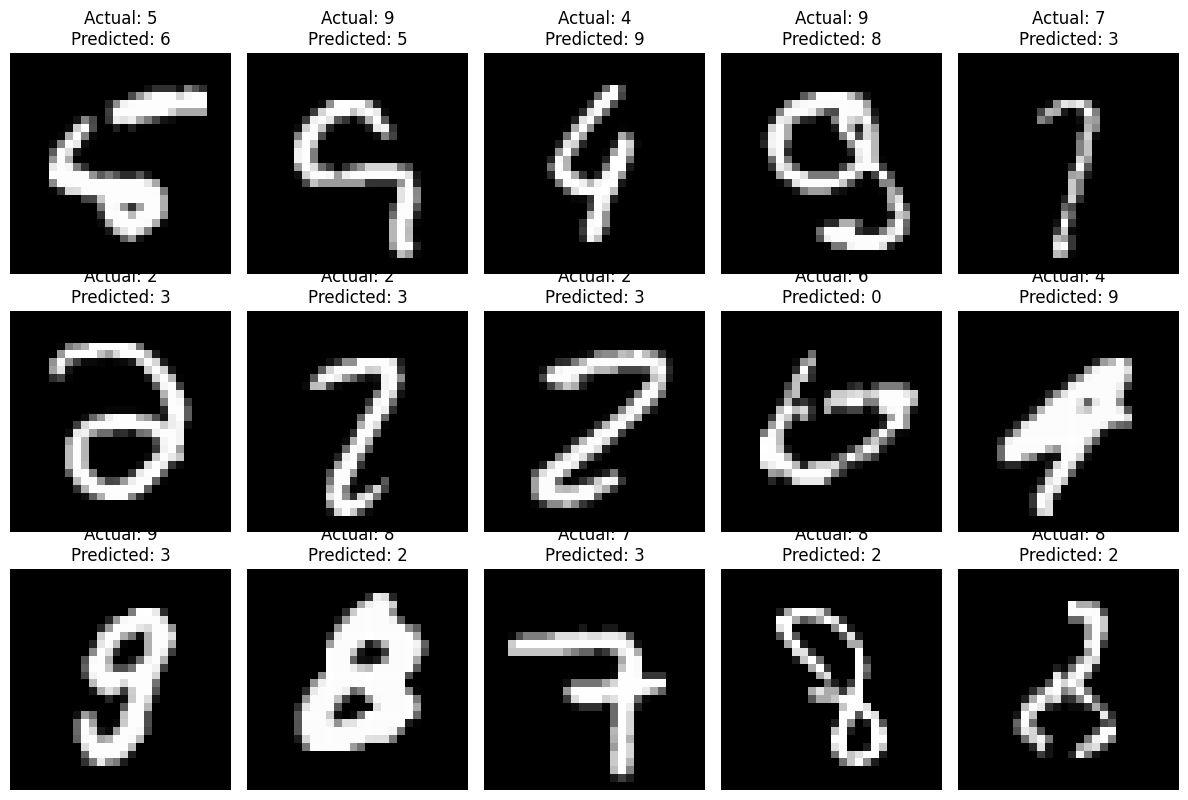

In [144]:
plt.figure(figsize=(12, 8))

for i in range(15):
    index = incorrect_indices[i]

    plt.subplot(3, 5, i + 1)

    plt.imshow(X_test[index], cmap="gray")

    plt.title(
        f"Actual: {y_test[index]}\n"
        f"Predicted: {rbm_predicted_labels[index]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [147]:
from google.colab import files

uploaded = files.upload()

Saving WhatsApp Image 2026-09-28 at 3.33.15 PM.jpeg to WhatsApp Image 2026-09-28 at 3.33.15 PM.jpeg


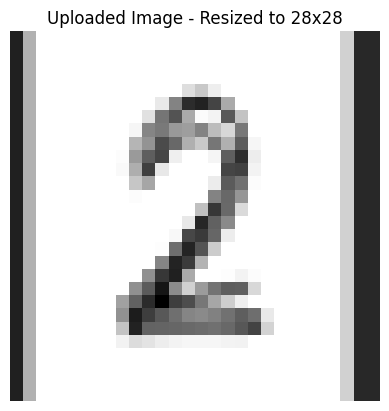

In [148]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

file_name = list(uploaded.keys())[0]

image = Image.open(file_name).convert("L")
image = image.resize((28, 28))

image_array = np.array(image)

plt.imshow(image_array, cmap="gray")
plt.title("Uploaded Image - Resized to 28x28")
plt.axis("off")
plt.show()

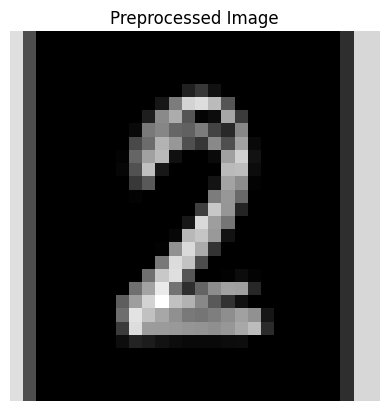

In [149]:
image_array = image_array.astype("float32") / 255.0

image_array = 1.0 - image_array

plt.imshow(image_array, cmap="gray")
plt.title("Preprocessed Image")
plt.axis("off")
plt.show()

In [150]:
image_flat = image_array.reshape(1, 784)

print("Image shape:", image_flat.shape)

Image shape: (1, 784)


In [151]:
image_rbm = rbm_256.transform(image_flat)

print("RBM feature shape:", image_rbm.shape)

RBM feature shape: (1, 256)


In [152]:
prediction = rbm256_ann.predict(image_rbm)

predicted_digit = np.argmax(prediction)
confidence = np.max(prediction)

print("Predicted Digit:", predicted_digit)
print("Confidence:", f"{confidence * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicted Digit: 2
Confidence: 51.48%


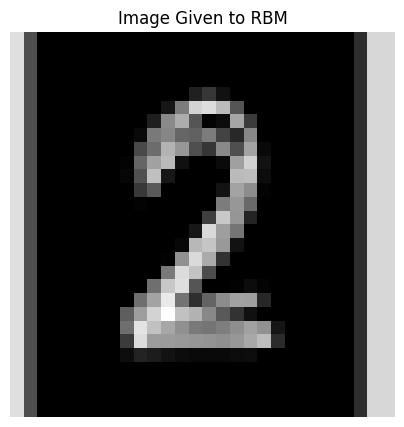

Minimum: 0.0
Maximum: 0.9764706


In [153]:
plt.figure(figsize=(5, 5))
plt.imshow(image_array, cmap="gray")
plt.title("Image Given to RBM")
plt.axis("off")
plt.show()

print("Minimum:", image_array.min())
print("Maximum:", image_array.max())

In [154]:
probabilities = prediction[0]

for digit, probability in enumerate(probabilities):
    print(f"Digit {digit}: {probability * 100:.2f}%")

Digit 0: 2.82%
Digit 1: 14.72%
Digit 2: 51.48%
Digit 3: 6.17%
Digit 4: 3.62%
Digit 5: 2.03%
Digit 6: 2.62%
Digit 7: 5.71%
Digit 8: 8.09%
Digit 9: 2.73%


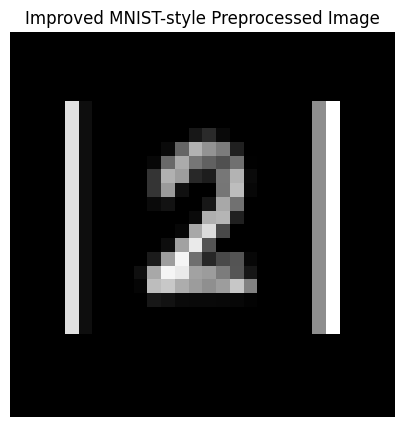

In [155]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Open original uploaded image
image = Image.open(file_name).convert("L")

# Convert to NumPy array
img = np.array(image)

# Invert: black digit on white background
img = 255 - img

# Find pixels belonging to the digit
coords = np.argwhere(img > 30)

# Get bounding box
y_min, x_min = coords.min(axis=0)
y_max, x_max = coords.max(axis=0)

# Crop only the digit
cropped = img[y_min:y_max + 1, x_min:x_max + 1]

# Convert cropped digit back to PIL
cropped_image = Image.fromarray(cropped)

# Resize while maintaining the digit's shape
cropped_image.thumbnail((20, 20))

# Create a 28x28 black canvas
canvas = Image.new("L", (28, 28), 0)

# Center the resized digit
x_offset = (28 - cropped_image.width) // 2
y_offset = (28 - cropped_image.height) // 2

canvas.paste(cropped_image, (x_offset, y_offset))

# Convert to NumPy and normalize
processed_image = np.array(canvas).astype("float32") / 255.0

# Display
plt.figure(figsize=(5, 5))
plt.imshow(processed_image, cmap="gray")
plt.title("Improved MNIST-style Preprocessed Image")
plt.axis("off")
plt.show()

In [156]:
# Flatten
processed_flat = processed_image.reshape(1, 784)

# RBM feature extraction
processed_rbm = rbm_256.transform(processed_flat)

# ANN prediction
processed_prediction = rbm256_ann.predict(processed_rbm)

# Get predicted digit
processed_digit = np.argmax(processed_prediction)
processed_confidence = np.max(processed_prediction)

print("Predicted Digit:", processed_digit)
print("Confidence:", f"{processed_confidence * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted Digit: 2
Confidence: 90.60%


In [157]:
for digit, probability in enumerate(processed_prediction[0]):
    print(f"Digit {digit}: {probability * 100:.2f}%")

Digit 0: 0.01%
Digit 1: 4.46%
Digit 2: 90.60%
Digit 3: 0.40%
Digit 4: 0.00%
Digit 5: 3.00%
Digit 6: 0.00%
Digit 7: 1.18%
Digit 8: 0.35%
Digit 9: 0.00%


In [158]:
from sklearn.metrics import classification_report

print("RBM + ANN Classification Report")
print(
    classification_report(
        y_test,
        rbm_predicted_labels
    )
)

RBM + ANN Classification Report
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.98      0.96      0.97      1032
           3       0.95      0.98      0.97      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.97      0.98       892
           6       0.99      0.98      0.98       958
           7       0.98      0.96      0.97      1028
           8       0.96      0.98      0.97       974
           9       0.97      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [159]:
rbm_384 = BernoulliRBM(
    n_components=384,
    learning_rate=0.01,
    batch_size=128,
    n_iter=20,
    random_state=42,
    verbose=True
)

In [160]:
rbm_384.fit(X_train_flat)

[BernoulliRBM] Iteration 1, pseudo-likelihood = -161.84, time = 11.11s
[BernoulliRBM] Iteration 2, pseudo-likelihood = -139.04, time = 12.90s
[BernoulliRBM] Iteration 3, pseudo-likelihood = -127.77, time = 12.82s
[BernoulliRBM] Iteration 4, pseudo-likelihood = -119.25, time = 12.75s
[BernoulliRBM] Iteration 5, pseudo-likelihood = -112.59, time = 12.78s
[BernoulliRBM] Iteration 6, pseudo-likelihood = -108.11, time = 12.60s
[BernoulliRBM] Iteration 7, pseudo-likelihood = -104.19, time = 10.66s
[BernoulliRBM] Iteration 8, pseudo-likelihood = -101.26, time = 11.47s
[BernoulliRBM] Iteration 9, pseudo-likelihood = -98.58, time = 12.03s
[BernoulliRBM] Iteration 10, pseudo-likelihood = -95.92, time = 12.57s
[BernoulliRBM] Iteration 11, pseudo-likelihood = -93.74, time = 12.52s
[BernoulliRBM] Iteration 12, pseudo-likelihood = -91.86, time = 12.58s
[BernoulliRBM] Iteration 13, pseudo-likelihood = -90.32, time = 12.58s
[BernoulliRBM] Iteration 14, pseudo-likelihood = -88.93, time = 12.59s
[Bernou

BernoulliRBM(batch_size=128, learning_rate=0.01, n_components=384, n_iter=20,
             random_state=42, verbose=True)

In [161]:
X_train_rbm384 = rbm_384.transform(X_train_flat)
X_test_rbm384 = rbm_384.transform(X_test_flat)

print("Training shape:", X_train_rbm384.shape)
print("Testing shape:", X_test_rbm384.shape)

Training shape: (60000, 384)
Testing shape: (10000, 384)


In [163]:
rbm384_ann = Sequential([
    Dense(128, activation="relu", input_shape=(384,)),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

In [164]:
rbm384_ann.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [165]:
history_rbm384 = rbm384_ann.fit(
    X_train_rbm384,
    y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8983 - loss: 0.3542 - val_accuracy: 0.9595 - val_loss: 0.1401
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9520 - loss: 0.1562 - val_accuracy: 0.9675 - val_loss: 0.1099
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9624 - loss: 0.1215 - val_accuracy: 0.9713 - val_loss: 0.0965
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9684 - loss: 0.1016 - val_accuracy: 0.9730 - val_loss: 0.0925
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9719 - loss: 0.0882 - val_accuracy: 0.9743 - val_loss: 0.0865
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9762 - loss: 0.0770 - val_accuracy: 0.9780 - val_loss: 0.0809
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9778 - loss: 0.0709 - val_accuracy: 0.9768 - val_loss: 0.0769
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9804 - loss: 0.0629 - val_accuracy: 0.

In [166]:
rbm384_loss, rbm384_accuracy = rbm384_ann.evaluate(
    X_test_rbm384,
    y_test,
    verbose=0
)

print("RBM + ANN (384 features) Accuracy:", rbm384_accuracy)

RBM + ANN (384 features) Accuracy: 0.9764000177383423


In [167]:
rbm384_predictions = rbm384_ann.predict(X_test_rbm384)

rbm384_predicted_labels = np.argmax(
    rbm384_predictions,
    axis=1
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [168]:
from sklearn.metrics import classification_report

print("Final RBM + ANN (384 Features) Classification Report")

print(
    classification_report(
        y_test,
        rbm384_predicted_labels
    )
)

Final RBM + ANN (384 Features) Classification Report
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.96      0.97      1032
           3       0.98      0.97      0.98      1010
           4       0.97      0.98      0.98       982
           5       0.97      0.99      0.98       892
           6       0.98      0.98      0.98       958
           7       0.99      0.96      0.97      1028
           8       0.94      0.99      0.97       974
           9       0.97      0.96      0.96      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



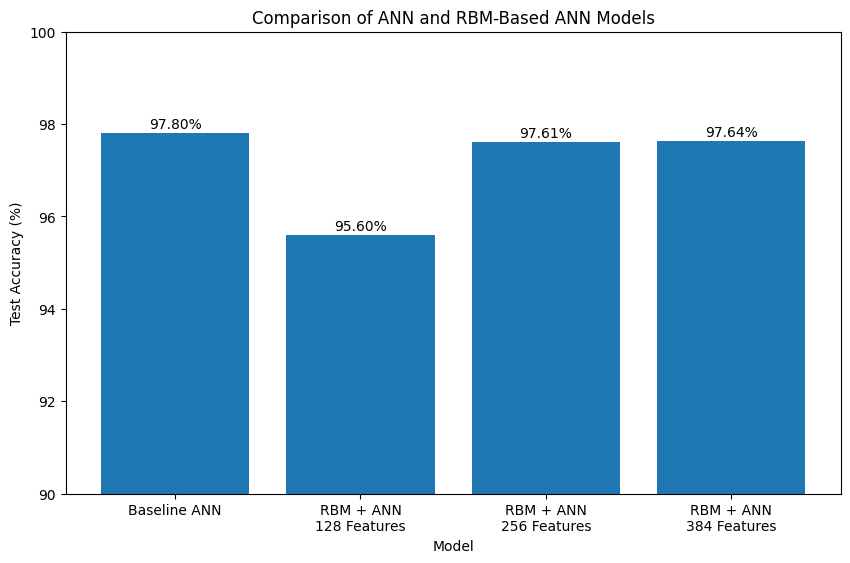

In [169]:
import matplotlib.pyplot as plt

models = [
    "Baseline ANN",
    "RBM + ANN\n128 Features",
    "RBM + ANN\n256 Features",
    "RBM + ANN\n384 Features"
]

accuracies = [
    baseline_accuracy * 100,
    rbm_ann_accuracy * 100,
    rbm256_accuracy * 100,
    rbm384_accuracy * 100
]

plt.figure(figsize=(10, 6))

bars = plt.bar(models, accuracies)

plt.ylabel("Test Accuracy (%)")
plt.xlabel("Model")
plt.title("Comparison of ANN and RBM-Based ANN Models")

plt.ylim(90, 100)

for bar, accuracy in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{accuracy:.2f}%",
        ha="center"
    )

plt.show()

In [170]:
import pandas as pd

final_results = pd.DataFrame({
    "Model": [
        "Baseline ANN",
        "RBM + ANN (128 Features)",
        "RBM + ANN (256 Features)",
        "RBM + ANN (384 Features)"
    ],
    "Features": [
        784,
        128,
        256,
        384
    ],
    "Test Accuracy (%)": [
        baseline_accuracy * 100,
        rbm_ann_accuracy * 100,
        rbm256_accuracy * 100,
        rbm384_accuracy * 100
    ]
})

final_results

,Model,Features,Test Accuracy (%)
0,Baseline ANN,784,97.799999
1,RBM + ANN (128 Features),128,95.599997
2,RBM + ANN (256 Features),256,97.610003
3,RBM + ANN (384 Features),384,97.640002
